In [7]:
# =========================
# STEP 0 — IMPORTS, PATH, FOLDERS
# =========================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For display in Jupyter
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x.head() if hasattr(x, "head") else x)

# >>> UPDATE THIS to your local CSV path
DATA_PATH = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Data\raw\diabetic_data.csv"

# === Absolute folders for saving results ===
EDA_DIR     = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations"
OUTPUTS_DIR = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Outputs"

# Create folders if not exist
os.makedirs(EDA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("EDA visualizations will be saved to:", EDA_DIR)
print("Outputs will be saved to:", OUTPUTS_DIR)

EDA visualizations will be saved to: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations
Outputs will be saved to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Outputs


In [8]:
# =========================
# STEP 1 — LOAD & PREVIEW
# =========================
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head(10))
display(df_raw.sample(5, random_state=7))
print("\nDtypes:")
print(df_raw.dtypes)

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,?,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,?,70,1,21,0,0,0,414,411,V45,7,NaN,NaN,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,?,73,0,12,0,0,0,428,492,250,8,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,?,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
91725,313105214,44510085,AfricanAmerican,Female,[50-60),?,3,1,1,1,MC,?,1,3,12,0,0,0,996,585,403,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
76741,232035120,94856616,Caucasian,Male,[80-90),?,2,1,7,4,MC,Emergency/Trauma,100,1,23,0,0,1,428,491,584,9,NaN,>7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
11792,48502758,8191152,Caucasian,Male,[60-70),?,1,18,7,6,?,?,55,0,13,0,0,0,250.02,414,331,7,NaN,>8,No,No,No,No,No,No,No,Up,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,>30
58861,166264734,79706430,Caucasian,Female,[30-40),[125-150),2,1,1,4,DM,ObstetricsandGynecology,35,3,14,0,0,0,641,648,250,9,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,>30
63383,176327694,23662620,AfricanAmerican,Female,[50-60),?,2,1,1,7,BC,Orthopedics-Reconstructive,38,2,28,0,0,0,250.7,785,681,5,NaN,NaN,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO



Dtypes:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride

Total missing values: 374020

Top missing columns:


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
gender                          3
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
patient_nbr                     0
discharge_disposition_id        0
admission_type_id               0
age                             0
number_inpatient                0
number_emergency                0
dtype: int64


Columns with > 60% missing (inspect / consider dropping):


weight           96.858479
max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64

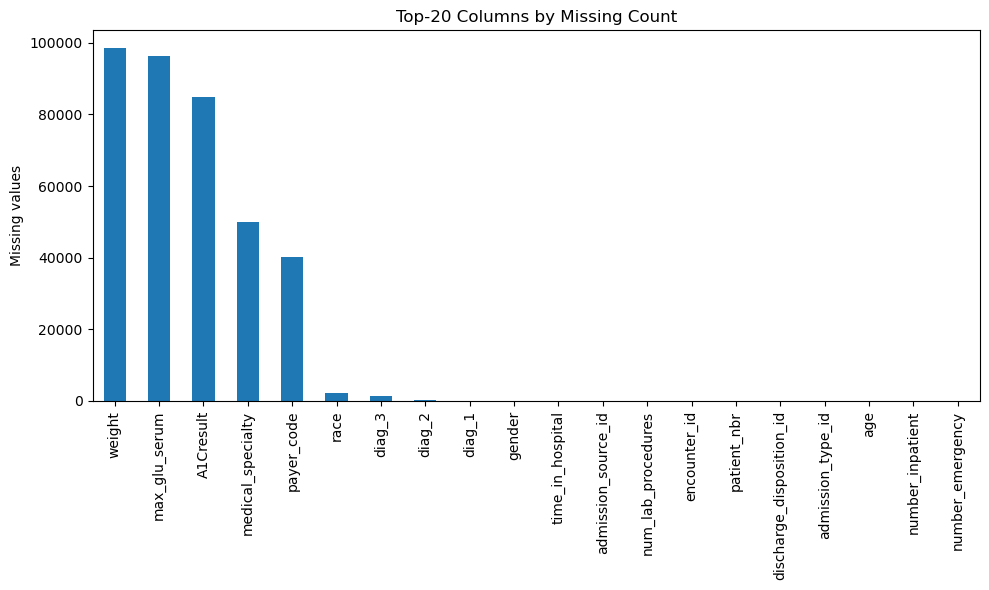

In [10]:
# =========================
# STEP 2 — PLACEHOLDERS → NaN & MISSING AUDIT
# =========================
PLACEHOLDERS = ["?", "Unknown/Invalid", "Unknown", "None", "N/A", "NA", "NULL", "Not Available"]
df = df_raw.replace(PLACEHOLDERS, np.nan)

missing_counts = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing_counts.sum()))
print("\nTop missing columns:")
display(missing_counts.head(20))

missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nColumns with > 60% missing (inspect / consider dropping):")
display(missing_ratio[missing_ratio > 60])

# Visual: top-20 missing columns
plt.figure(figsize=(10, 6))
missing_counts.head(20).plot(kind="bar")
plt.title("Top-20 Columns by Missing Count")
plt.ylabel("Missing values")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "missing_top20.png"), dpi=150)
plt.show()

In [6]:
# =========================
# STEP 3 — DROP IRRELEVANT / ULTRA-HIGH-NA COLUMNS
# =========================
# Baseline rule: drop columns > 90% missing (adjust if needed).
HIGH_NA_THRESHOLD = 0.90
auto_drop = [c for c in df.columns if df[c].isna().mean() > HIGH_NA_THRESHOLD]

# Keep these if you want categorical signal later:
for keep_col in ["max_glu_serum", "A1Cresult"]:
    if keep_col in auto_drop:
        auto_drop.remove(keep_col)

# Example common: 'weight' is often ~97% missing — drop if present
DROP_COLS = sorted(set(auto_drop))
print("Auto high-NA drop candidates:", DROP_COLS)

if DROP_COLS:
    df = df.drop(columns=DROP_COLS)
print("Shape after high-NA drops:", df.shape)

Auto high-NA drop candidates: ['weight']
Shape after high-NA drops: (101766, 49)


In [11]:
# =========================
# STEP 4 — DUPLICATES & CONSISTENCY
# =========================
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
if dup_count > 0:
    df = df.drop_duplicates()
    print("Removed duplicates. New shape:", df.shape)

# Strip whitespace in object columns
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Optional: normalize some categories
if "gender" in df.columns:
    df["gender"] = df["gender"].str.title()


Duplicate rows: 0


In [12]:
# =========================
# STEP 5 — TYPES & SAFE NUMERIC CONVERSIONS
# =========================
print("Dtypes before conversion:")
print(df.dtypes)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols  = df.select_dtypes(include=["object"]).columns.tolist()
print("\nNumeric cols:", numeric_cols)
print("Object cols (first 20):", object_cols[:20], " ...")

def is_mostly_numeric(series, thresh=0.9):
    s = series.dropna().astype(str)
    if s.empty:
        return False
    pattern = re.compile(r"^[+-]?\d+(\.\d+)?$")
    numeric_like = s.apply(lambda v: bool(pattern.match(v)))
    return numeric_like.mean() >= thresh

converted_cols = []
for col in object_cols:
    if is_mostly_numeric(df[col], thresh=0.9):
        df[col] = pd.to_numeric(df[col], errors="coerce")
        converted_cols.append(col)

if converted_cols:
    print("Object→numeric conversions:", converted_cols)

# Refresh lists
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols  = df.select_dtypes(include=["object"]).columns.tolist()


Dtypes before conversion:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              o

In [13]:
# =========================
# STEP 6 — IMPUTE MISSING VALUES
# =========================
# Numeric -> median; Categorical -> mode (fallback 'Unknown')
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in object_cols:
    if df[col].isna().any():
        mode = df[col].mode(dropna=True)
        fill_val = mode.iloc[0] if not mode.empty else "Unknown"
        df[col] = df[col].fillna(fill_val)

print("Remaining total missing values after imputation:", int(df.isna().sum().sum()))


Remaining total missing values after imputation: 0


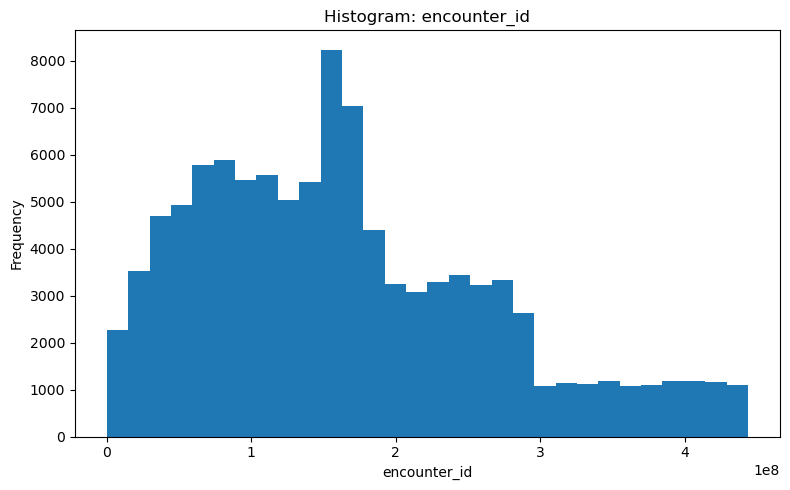

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_encounter_id.png


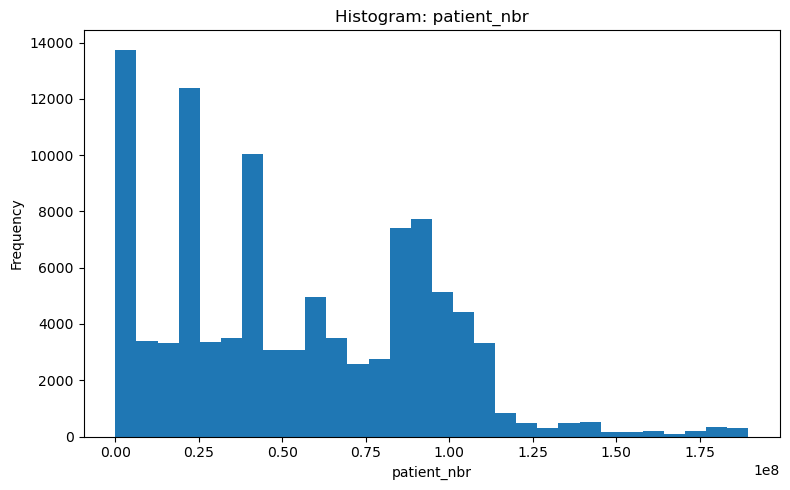

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_patient_nbr.png


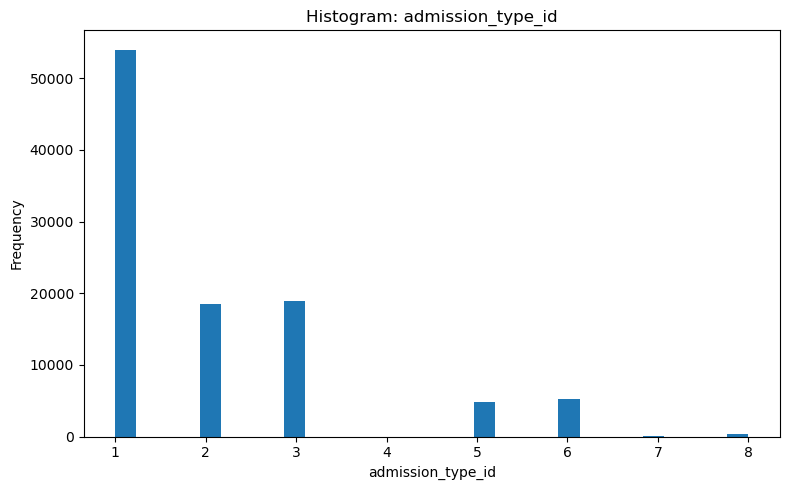

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_admission_type_id.png


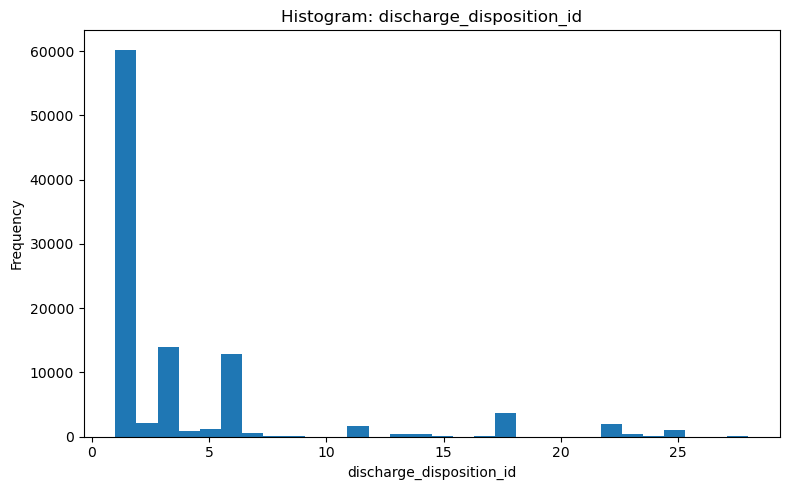

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_discharge_disposition_id.png


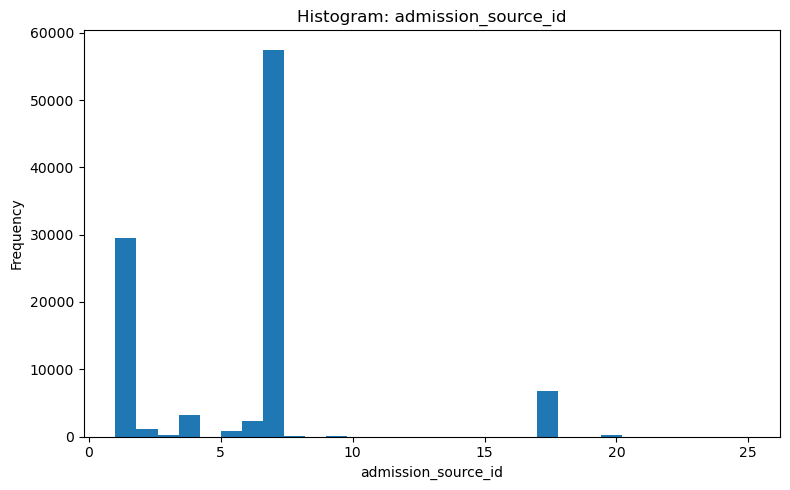

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_admission_source_id.png


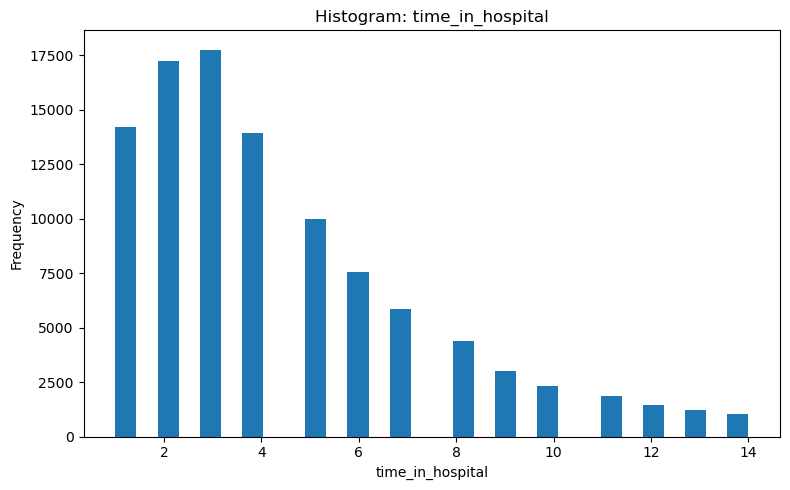

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_time_in_hospital.png


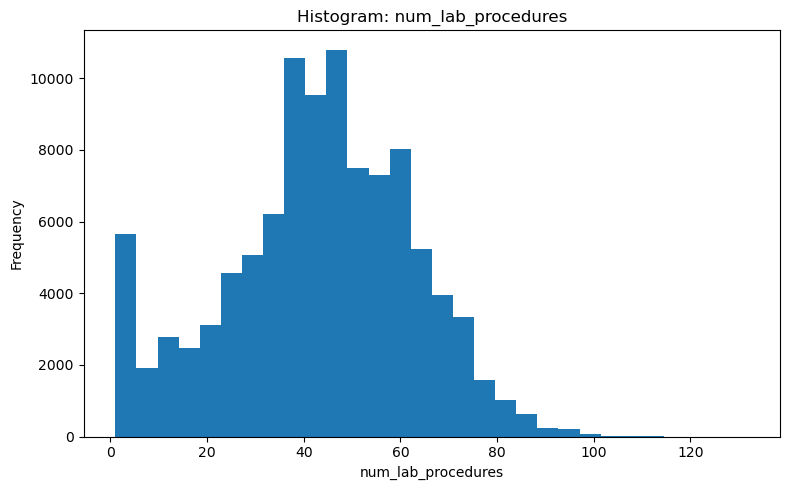

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_num_lab_procedures.png


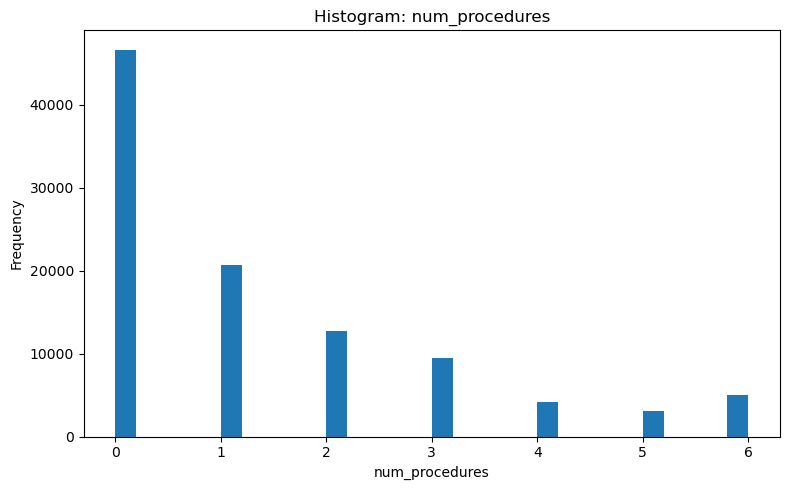

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\hist_num_procedures.png


In [14]:
# =========================
# STEP 7 — HISTOGRAMS (NUMERIC)
# =========================
num_cols_plot = [c for c in df.select_dtypes(include=[np.number]).columns if df[c].nunique() > 5]
num_cols_plot = num_cols_plot[:8]  # limit to avoid too many figures

for col in num_cols_plot:
    plt.figure(figsize=(8,5))
    df[col].plot(kind="hist", bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Frequency")
    plt.tight_layout()
    out = os.path.join(EDA_DIR, f"hist_{col}.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)


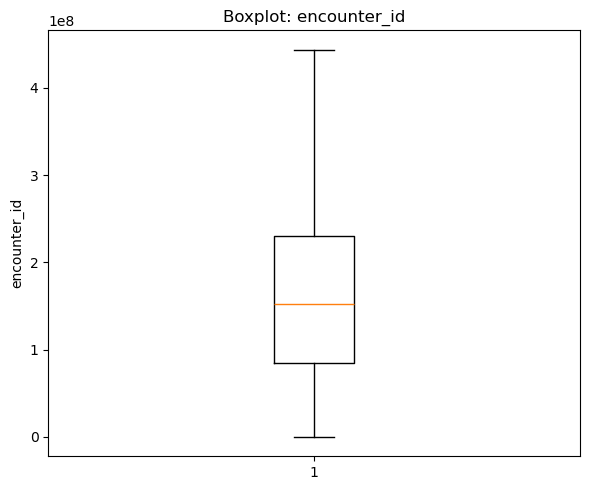

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_encounter_id.png


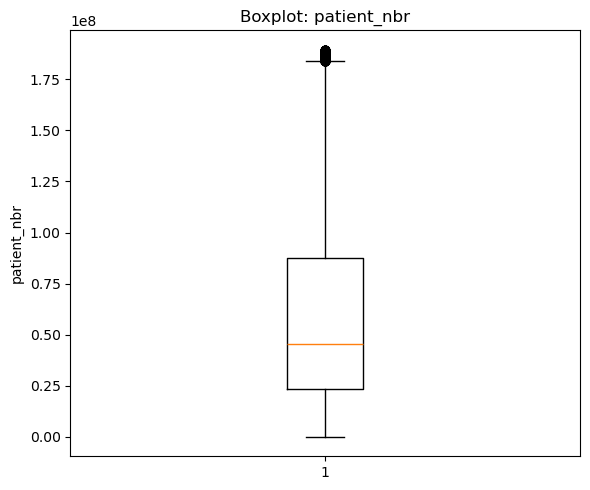

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_patient_nbr.png


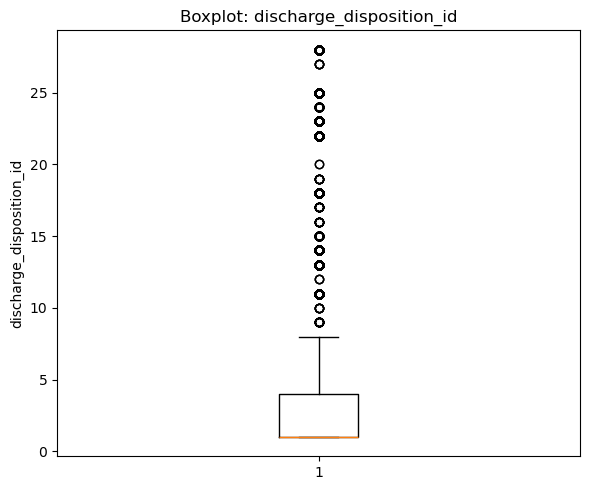

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_discharge_disposition_id.png


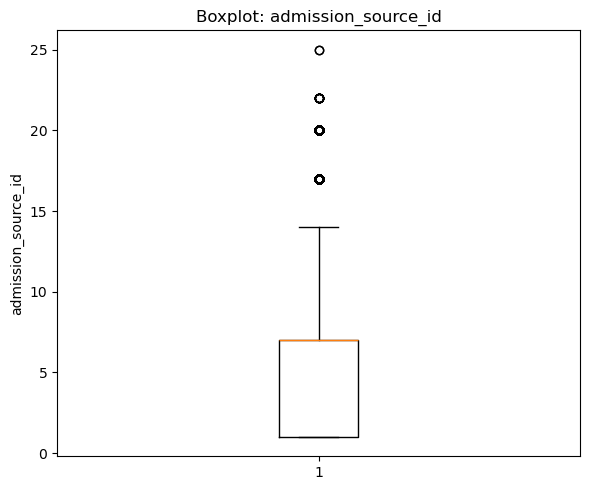

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_admission_source_id.png


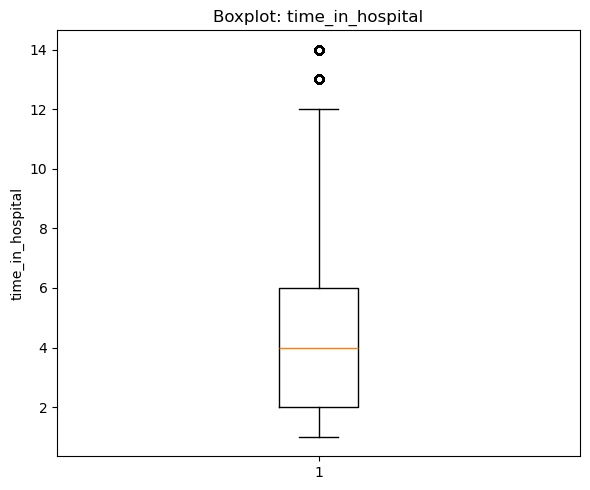

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_time_in_hospital.png


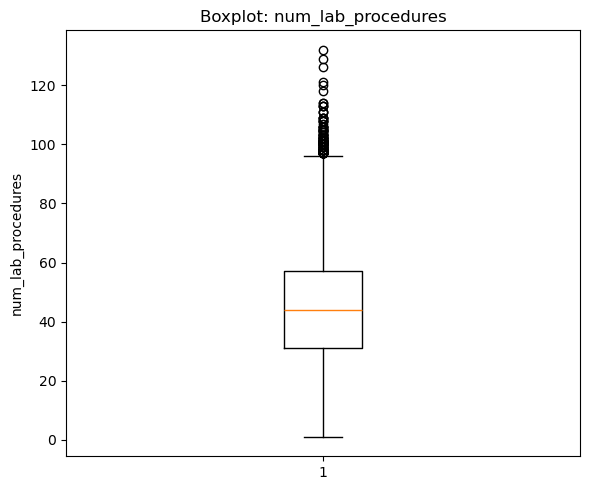

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\box_num_lab_procedures.png


In [15]:
# =========================
# STEP 8 — BOXPLOTS (OUTLIER VIEW)
# =========================
box_cols = [c for c in df.select_dtypes(include=[np.number]).columns if df[c].nunique()>10][:6]
for col in box_cols:
    plt.figure(figsize=(6,5))
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.tight_layout()
    out = os.path.join(EDA_DIR, f"box_{col}.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)

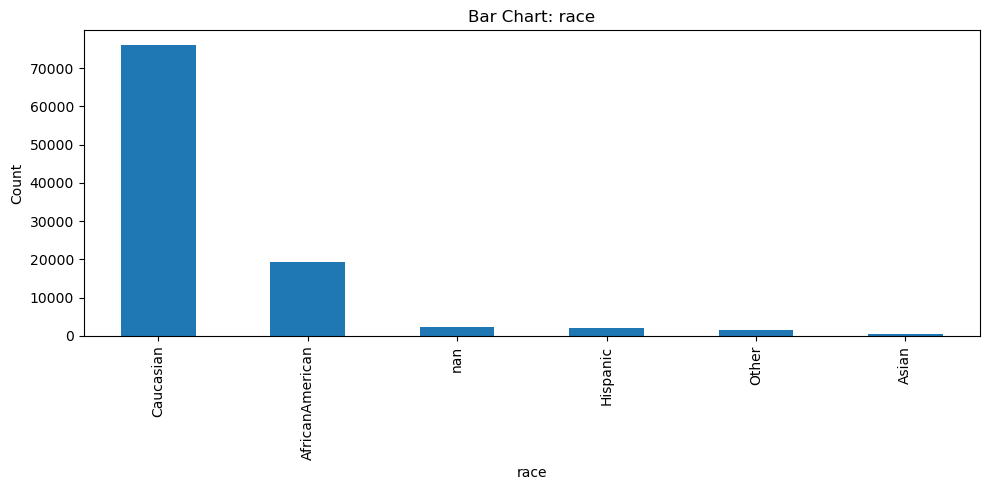

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_race.png


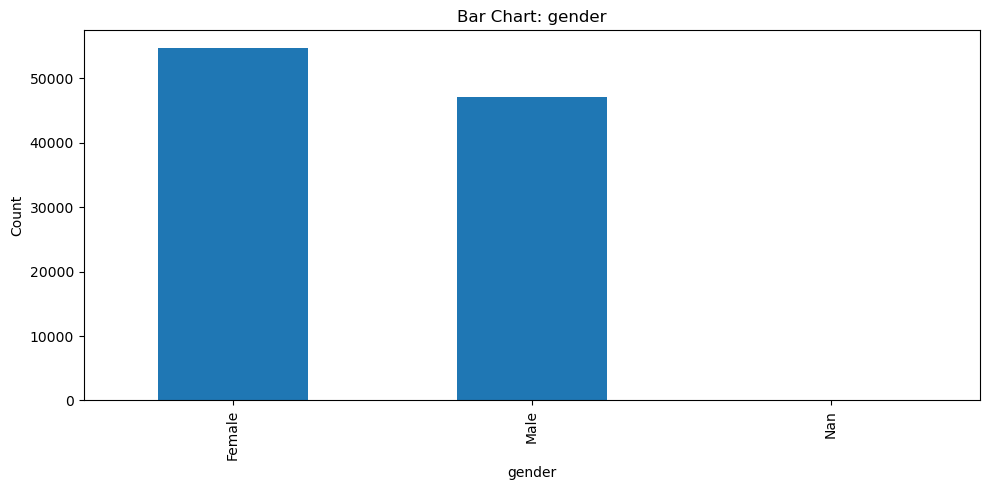

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_gender.png


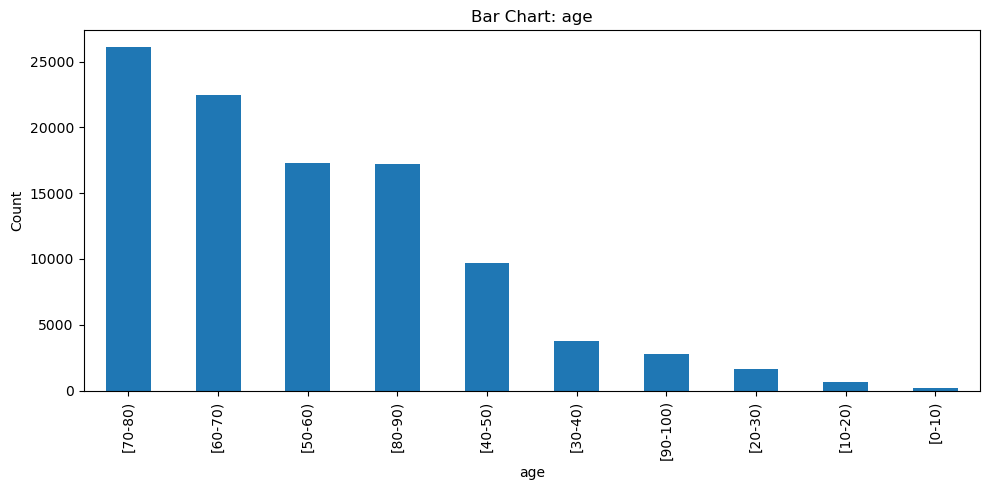

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_age.png


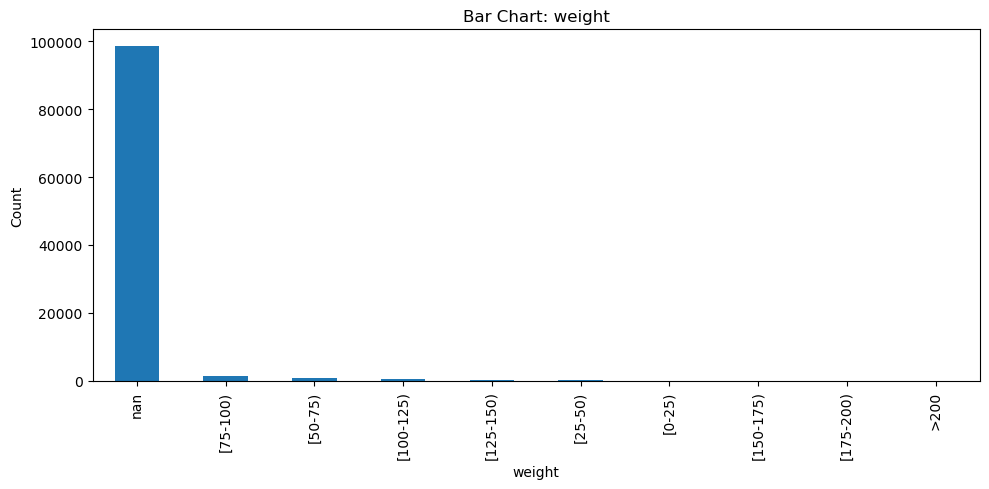

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_weight.png


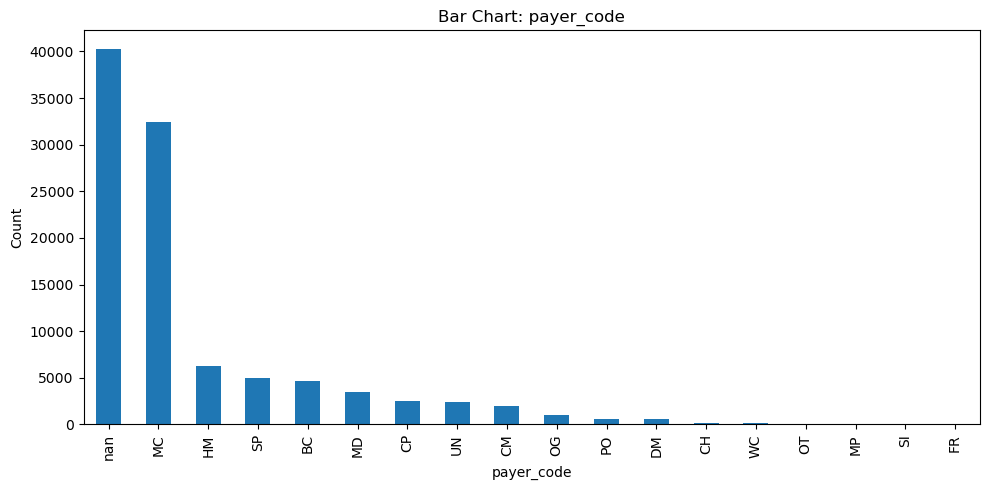

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_payer_code.png


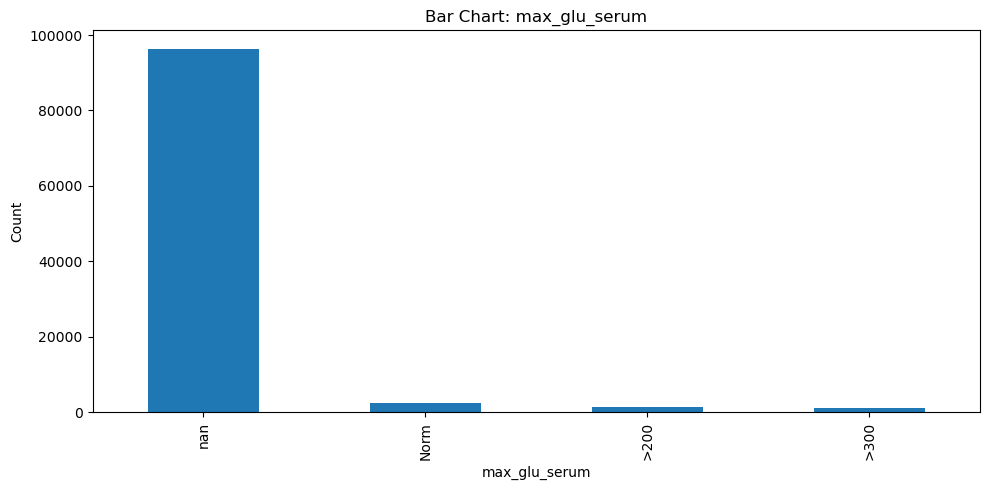

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\bar_max_glu_serum.png


In [16]:
# =========================
# STEP 9 — BARCHARTS (CATEGORICAL)
# =========================
cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if df[c].nunique() <= 25][:6]
for col in cat_cols:
    vc = df[col].value_counts(dropna=False).head(20)
    plt.figure(figsize=(10,5))
    vc.plot(kind="bar")
    plt.title(f"Bar Chart: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout()
    out = os.path.join(EDA_DIR, f"bar_{col}.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)

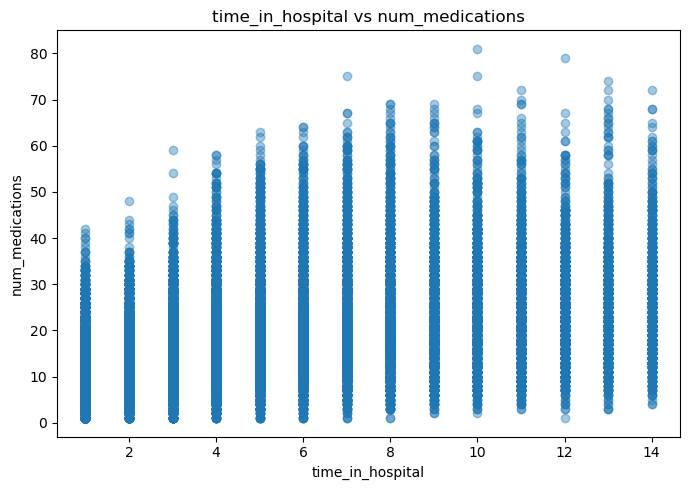

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\scatter_time_in_hospital_vs_num_medications.png


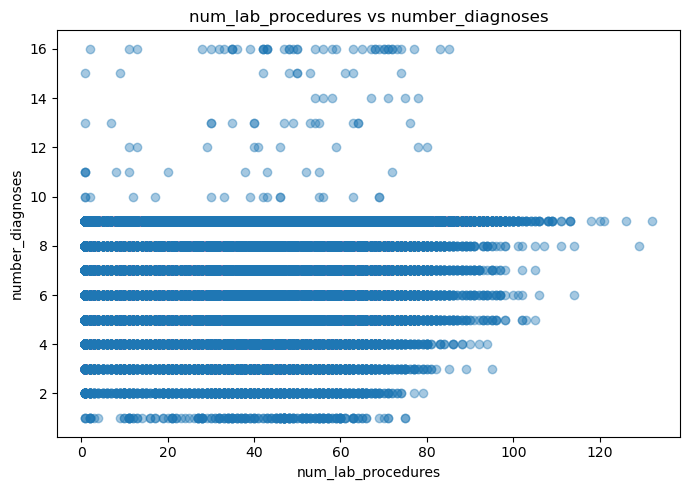

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\scatter_num_lab_procedures_vs_number_diagnoses.png


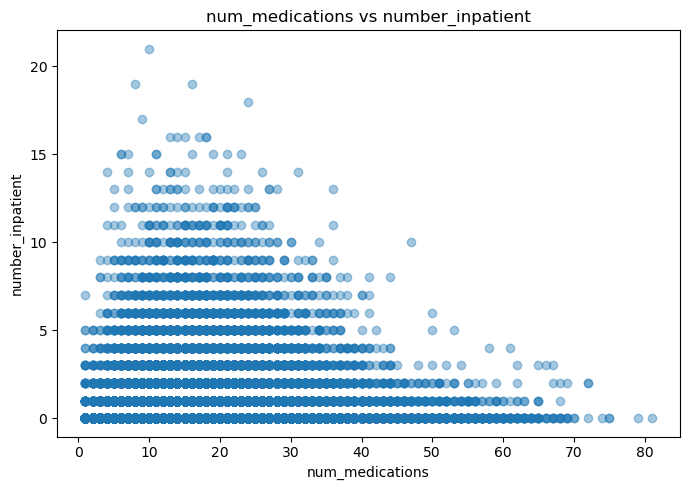

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\scatter_num_medications_vs_number_inpatient.png


In [30]:
# =========================
# STEP 10 — SCATTER PAIRS (NUMERIC↔NUMERIC)
# =========================
pairs = [
    ("time_in_hospital", "num_medications"),
    ("num_lab_procedures", "number_diagnoses"),
    ("num_medications", "number_inpatient"),
]

for xcol, ycol in pairs:
    if all(c in df.columns for c in [xcol, ycol]) and \
       pd.api.types.is_numeric_dtype(df[xcol]) and pd.api.types.is_numeric_dtype(df[ycol]):
        plt.figure(figsize=(7,5))
        plt.scatter(df[xcol], df[ycol], alpha=0.4)
        plt.title(f"{xcol} vs {ycol}")
        plt.xlabel(xcol); plt.ylabel(ycol)
        plt.tight_layout()
        out = os.path.join(EDA_DIR, f"scatter_{xcol}_vs_{ycol}.png")
        plt.savefig(out, dpi=150)
        plt.show()
        print("Saved:", out)


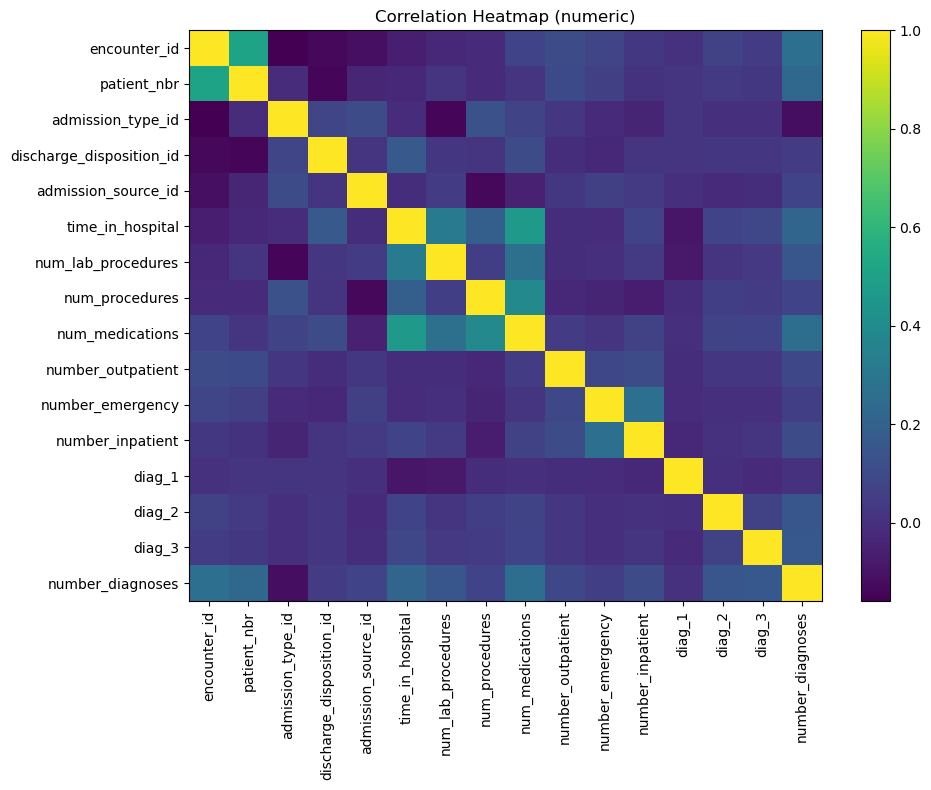

Saved: C:\Users\dusik\OneDrive\Desktop\Y2S1\eda_visualizations\correlation_heatmap.png


In [17]:
# =========================
# STEP 11 — CORRELATION HEATMAP
# =========================
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] > 1:
    corr = num_df.corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect="auto")
    plt.title("Correlation Heatmap (numeric)")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.tight_layout()
    out = os.path.join(EDA_DIR, "correlation_heatmap.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)
else:
    print("Not enough numeric columns for correlation heatmap.")


In [19]:
# =========================
# STEP 12 — IQR OUTLIER REPORT
# =========================
def iqr_outlier_report(frame: pd.DataFrame, cols):
    rows = []
    for col in cols:
        if col in frame.columns and pd.api.types.is_numeric_dtype(frame[col]):
            s = frame[col].dropna()
            if s.empty:
                continue
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            n_out = int(((frame[col] < lower) | (frame[col] > upper)).sum())
            rows.append({
                "column": col, "q1": q1, "q3": q3, "iqr": iqr,
                "lower_bound": lower, "upper_bound": upper,
                "n_outliers": n_out
            })
    rep = pd.DataFrame(rows)
    return rep.sort_values("n_outliers", ascending=False) if not rep.empty else rep

# make sure df exists; then:
num_df = df.select_dtypes(include=[np.number])  # <- define num_df here

iqr_report = iqr_outlier_report(df, num_df.columns.tolist())
display(iqr_report.head(20))

# use OUTPUTS_DIR (not OUT_DIR)
iqr_path = os.path.join(OUTPUTS_DIR, "iqr_outlier_report.csv")
iqr_report.to_csv(iqr_path, index=False)
print("Saved IQR report to:", iqr_path)

,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers
9,number_outpatient,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,16739
10,number_emergency,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,11383
3,discharge_disposition_id,1.0,4.000000e+00,3.000000e+00,-3.500000e+00,8.500000e+00,9818
11,number_inpatient,0.0,1.000000e+00,1.000000e+00,-1.500000e+00,2.500000e+00,7049
4,admission_source_id,1.0,7.000000e+00,6.000000e+00,-8.000000e+00,1.600000e+01,6956
12,diag_1,410.0,5.940000e+02,1.840000e+02,1.340000e+02,8.700000e+02,6696
7,num_procedures,0.0,2.000000e+00,2.000000e+00,-3.000000e+00,5.000000e+00,4954
8,num_medications,10.0,2.000000e+01,1.000000e+01,-5.000000e+00,3.500000e+01,2557
5,time_in_hospital,2.0,6.000000e+00,4.000000e+00,-4.000000e+00,1.200000e+01,2252
13,diag_2,278.0,5.180000e+02,2.400000e+02,-8.200000e+01,8.780000e+02,1795


Saved IQR report to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Outputs\iqr_outlier_report.csv


In [20]:
# =========================
# STEP 13 — SAVE CLEANED DATASET
# =========================
cleaned_path = os.path.join(OUTPUTS_DIR, "cleaned_diabetic_data.csv")
df.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to:", cleaned_path)

Saved cleaned dataset to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Outputs\cleaned_diabetic_data.csv
